## 1) Importar bibliotecas

In [3]:
from sklearn.model_selection import train_test_split, learning_curve, LearningCurveDisplay
from sklearn.metrics import PredictionErrorDisplay
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt

import polars as pl
import numpy as np

## 2) Ler base de dados

In [4]:
data = pl.read_parquet(
    source = "./diabetes_dataset.parquet"
)

print(data.shape)
data.head(2)

(442, 11)


age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
i8,i8,f32,f32,f32,f32,f32,f32,f32,f32,f32
59,2,32.099998,101.0,157.0,93.199997,38.0,4.0,4.8598,87.0,151.0
48,1,21.6,87.0,183.0,103.199997,70.0,3.0,3.8918,69.0,75.0


## 3) Treinamento do modelo

### 3.1) Separar por `train_test_split`:

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    data.drop("target"),
    data["target"],
    random_state = 1,
    train_size = 0.7,
)

for array in [X_train, X_test, y_train, y_test]:
    print(array.shape)

(309, 10)
(133, 10)
(309,)
(133,)


### 3.2) Treinar modelo:

In [6]:
model = LinearRegression()

model.fit(
    X = X_train,
    y = y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 4) Avaliar modelo:

#### 4.1) `PredictionErrorDisplay`:

Modelos de Regressão Linear podem ser avaliados com uma nova métrica da biblioteca `sklearn` chamado `PredictionErrorDisplay`.

Basicamente, ele avalia se o modelo linear está errando acima ou abaixo do esperado.

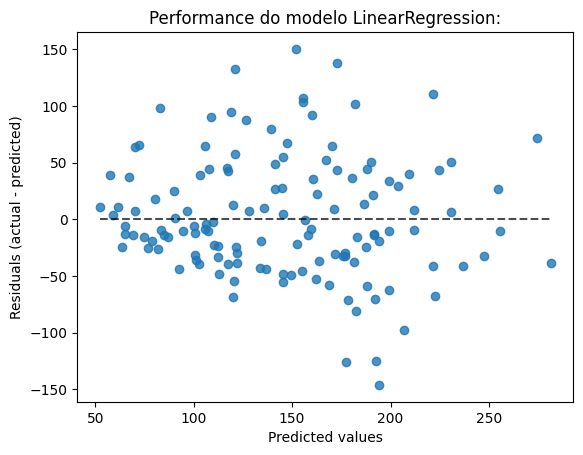

In [ ]:
display = PredictionErrorDisplay(
    y_true = y_test,
    y_pred = model.predict(
        X = X_test
    )
)

display.plot()
plt.title("Performance do modelo LinearRegression (Sem pré-processamento):")
plt.show()

### 4.2) `learning_curve`:

Para avaliar a evolução do aprendizado conforme tamanho do dataset de treino, podemos usar o `learning_curve` para ver até onde o modelo começa a operar conforme esperado.

In [8]:
learning_curve_results = learning_curve(
    estimator = model,
    X = data.drop("target"),
    y = data["target"],
    shuffle = True,
    random_state = 1,
    train_sizes = np.linspace(start = 0.01, stop = 1, num = 10)
)

print(learning_curve_results)

(array([  3,  42,  81, 120, 158, 197, 236, 275, 314, 353]), array([[1.        , 1.        , 1.        , 1.        , 1.        ],
       [0.58996695, 0.5471338 , 0.58925217, 0.80136454, 0.59528053],
       [0.61176455, 0.53538883, 0.48693752, 0.72679967, 0.59473968],
       [0.58374566, 0.5394789 , 0.45188433, 0.6604774 , 0.54397833],
       [0.5830732 , 0.54743844, 0.48093033, 0.6282264 , 0.54233307],
       [0.57013333, 0.54942769, 0.46827435, 0.58269775, 0.55153072],
       [0.55813026, 0.54968143, 0.49496675, 0.55684119, 0.51357102],
       [0.54488683, 0.54142374, 0.4991141 , 0.53554654, 0.50429821],
       [0.52312428, 0.52036858, 0.52711093, 0.53496408, 0.51722062],
       [0.52428269, 0.51032126, 0.52498507, 0.53166592, 0.50784832]]), array([[-0.86359739, -0.43794763, -0.53430486, -2.86410832, -1.24913836],
       [-0.16422331,  0.41668975,  0.34466332,  0.22831267,  0.355178  ],
       [ 0.26768869,  0.51532888,  0.38577127,  0.38554662,  0.48975849],
       [ 0.35544538,  0.49

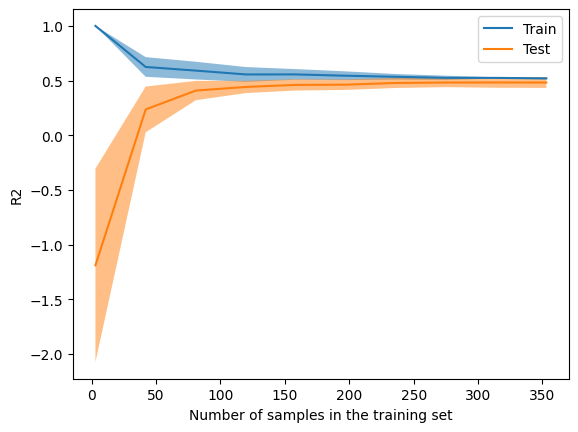

In [9]:
display_learning_curve = LearningCurveDisplay(
    train_sizes = learning_curve_results[0],
    train_scores = learning_curve_results[1],
    test_scores = learning_curve_results[2],
    score_name = "R2"
)

display_learning_curve.plot()

## 5) Criar Pipeline

### 5.1) `ColumnTransformer`

No caso, o método `ColumnTransformer` garante que o `Pipeline` - que é na verdade um sequenciamento de etapas pré-determinadas pelo programador - opere com os dados processados em escala e em formato ideal.

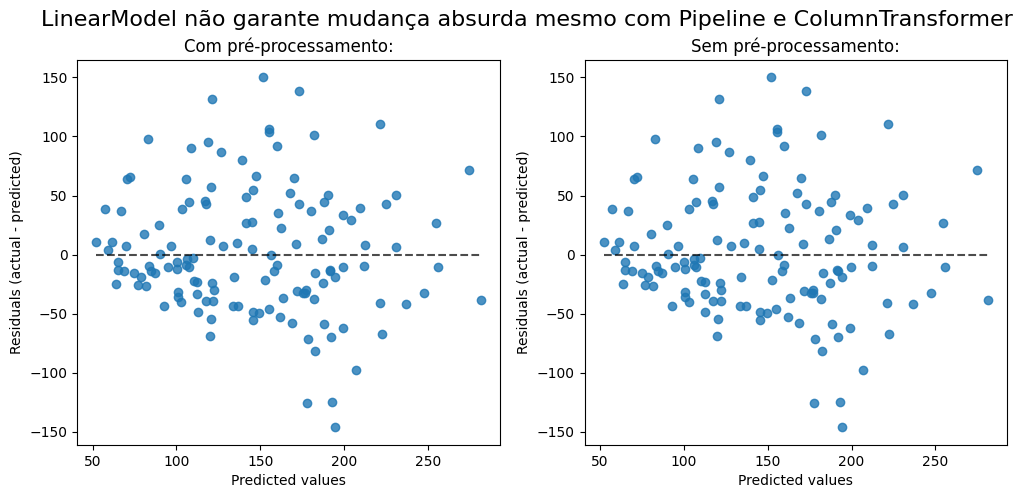

In [29]:
column_transformer = ColumnTransformer(
    transformers = [
        ("OneHotEnc", OneHotEncoder(drop = "if_binary"), ["sex"]),
        ("StandartScaler", StandardScaler(), ["age", "bmi", "bp", "s1", "s2", "s3", "s4", "s5", "s6"])
    ]
)

pipeline = Pipeline(
    steps = [
        ("preprocessing", column_transformer),
        ("linear_model", LinearRegression())
    ]
)

pipeline.fit(
    X = X_train, y = y_train
)

fig, axs = plt.subplots(
    ncols = 2,
    figsize = (12, 5)
)

display1 = PredictionErrorDisplay(
    y_true = y_test,
    y_pred = pipeline.predict(
        X = X_test
    )
)

display2 = PredictionErrorDisplay(
    y_true = y_test,
    y_pred = model.predict(
        X = X_test
    )
)

display1.plot(ax = axs[0])
display2.plot(ax = axs[1])

axs[0].set_title("Com pré-processamento:")
axs[1].set_title("Sem pré-processamento:")

plt.suptitle("LinearModel não garante mudança absurda mesmo com Pipeline e ColumnTransformer", fontsize = 16)
plt.show()

In [26]:
pipeline["linear_model"].coef_

array([-22.69046703,  -0.63290146,  28.12590812,  15.89995762,
       -31.56302973,  16.3531121 ,   4.2066783 ,  10.37107075,
        32.52885731,   2.23249873])

In [27]:
model.coef_

array([-4.8333403e-02, -2.2690487e+01,  6.2752018e+00,  1.1902523e+00,
       -8.9102936e-01,  5.3370953e-01,  3.3199739e-01,  8.0301495e+00,
        6.0578629e+01,  1.9104862e-01], dtype=float32)